# **DM Python pour la Datascience**

### Import des données

In [15]:
import pandas as pd
from great_tables import GT, style, loc,md
from matplotlib import pyplot as plt

In [16]:
df = pd.read_csv(
'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)
df.head()

/tmp/ipykernel_8222/518893530.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


## 1. Explorations générales
### Question 1

In [17]:
df['code_commune'] = df['code_departement'].astype(str) + df['code_commune'].astype(str).str.zfill(3)
df.head()

df['candidat'] = df['prenom'] + ' ' + df['nom']
df.tail()


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
528670,fr_etranger,Français établis hors de France,fr_etranger229,Zurich,NaN,nuls,31,NaN
528671,fr_etranger,Français établis hors de France,fr_etranger231,Taipei,NaN,nuls,2,NaN
528672,fr_etranger,Français établis hors de France,fr_etranger233,Nour-Soultan,NaN,nuls,0,NaN
528673,fr_etranger,Français établis hors de France,fr_etranger234,Monterrey,NaN,nuls,2,NaN
528674,fr_etranger,Français établis hors de France,fr_etranger235,Bahamas (Nassau),NaN,nuls,0,NaN


### Question 2

In [18]:
nombre_candidats = df['candidat'].nunique()
print(f"En 2022, il y avait {nombre_candidats} candidats à l’élection présidentielle.")

En 2022, il y avait 12 candidats à l’élection présidentielle.


### Question 3

In [ ]:
scores_nationaux = df.groupby('candidat')['voix'].sum().reset_index()
scores_nationaux['pourcentage'] = (scores_nationaux['voix'] / scores_nationaux['voix'].sum()) * 100
scores_nationaux = scores_nationaux.sort_values(by='voix', ascending=False)
scores_nationaux.head()


,candidat,voix,pourcentage
1,Emmanuel MACRON,9783058,27.845822
5,Marine LE PEN,8133828,23.151568
4,Jean-Luc MÉLENCHON,7712520,21.952386
11,Éric ZEMMOUR,2485226,7.073776
9,Valérie PÉCRESSE,1679001,4.778993


In [20]:
scores_nationaux = df.groupby('candidat')['voix'].sum().reset_index()
scores_nationaux['pourcentage'] = (scores_nationaux['voix'] / scores_nationaux['voix'].sum()) * 100
scores_nationaux = scores_nationaux.sort_values(by='voix', ascending=False).reset_index(drop=True)


scores_nationaux.insert(0, 'rang', range(1, len(scores_nationaux) + 1))

scores_nationaux['voix_fmt'] = scores_nationaux['voix'].apply(lambda x: f"{x:,.0f}".replace(",", " "))
scores_nationaux['pct_fmt'] = scores_nationaux['pourcentage'].apply(lambda x: f"{x:.2f} %")

# Tableau Great_tables
(
    GT(scores_nationaux[["candidat", "voix_fmt", "pct_fmt"]])
    .tab_header(title=md("**Election**"), subtitle="Résultats du premier tour (📅 10 avril 2022)")
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.body())
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.column_labels())
    .tab_style(style=style.text(font="Times New Roman", align="center"), locations=loc.title())
    .tab_style(style=style.text(font="Times New Roman", align="center"), locations=loc.subtitle())
    .cols_label(candidat="Candidat", voix_fmt="Nombre votes (total)", pct_fmt="Score (% votes exprimés)")
)


GT(_tbl_data=                 candidat   voix_fmt  pct_fmt
0         Emmanuel MACRON  9 783 058  27.85 %
1           Marine LE PEN  8 133 828  23.15 %
2      Jean-Luc MÉLENCHON  7 712 520  21.95 %
3            Éric ZEMMOUR  2 485 226   7.07 %
4        Valérie PÉCRESSE  1 679 001   4.78 %
5           Yannick JADOT  1 627 853   4.63 %
6           Jean LASSALLE  1 101 387   3.13 %
7          Fabien ROUSSEL    802 422   2.28 %
8   Nicolas DUPONT-AIGNAN    725 176   2.06 %
9            Anne HIDALGO    616 478   1.75 %
10        Philippe POUTOU    268 904   0.77 %
11       Nathalie ARTHAUD    197 094   0.56 %, _body=<great_tables._gt_data.Body object at 0x7fa61031bdf0>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix_fmt', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='pct_fmt', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fa6096ec050>, _spanners=Spanners([]), _heading=Heading(title=Md(text='**Election**'), subtitle='Résultats du premier tour (📅 10 avril 2022)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fa60ba109d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fa6096f05f0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=0, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=1, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=2, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=3, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=4, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=5, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=6, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='candidat', rownum=7, colnum=None, styles=[CellStyleText(color=None, font='Times New Roman', size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, r

## 2. Comparaison des scores départements aux moyennes nationales.
### Question 4

In [21]:
score_departements = df.groupby(['code_departement', 'candidat'])['voix'].sum().reset_index()
score_departements['score'] = (score_departements['voix'] / score_departements.groupby('code_departement')['voix'].transform('sum')) * 100
score_departements= score_departements.rename(columns={"voix": "votes"})

score_departement_11 = score_departements[score_departements['code_departement'] == "11"].sort_values(by='score', ascending=False).reset_index(drop=True)
score_departement_11["score"] = score_departement_11["score"].apply(lambda x: f"{x:.2f} %")

(
    GT(score_departement_11[["code_departement", "candidat", "votes", "score"]])
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.body())
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.column_labels())

)

code_departement,candidat,votes,score
11,Marine LE PEN,64027,30.14 %
11,Emmanuel MACRON,43104,20.29 %
11,Jean-Luc MÉLENCHON,42039,19.79 %
11,Éric ZEMMOUR,18434,8.68 %
11,Jean LASSALLE,12382,5.83 %
11,Valérie PÉCRESSE,7350,3.46 %
11,Yannick JADOT,6322,2.98 %
11,Anne HIDALGO,6166,2.90 %
11,Fabien ROUSSEL,5622,2.65 %
11,Nicolas DUPONT-AIGNAN,4206,1.98 %


### Question 5

In [22]:
score_departements = score_departements.merge(scores_nationaux[['candidat', 'voix', 'pourcentage']],
                                              on='candidat',
                                              how='left')

score_departements = score_departements.rename(columns={"votes": "votes_departement",
                                                        "score":"score_departement",
                                                        "voix": "votes_national",
                                                        "pourcentage": "score_national"})

score_departement_11 = score_departements[score_departements['code_departement'] == "11"].sort_values(by='score_departement', ascending=False).reset_index(drop=True)
score_departement_11["score_departement"] = score_departement_11["score_departement"].apply(lambda x: f"{x:.2f} %")
score_departement_11["score_national"] = score_departement_11["score_national"].apply(lambda x: f"{x:.2f} %")


score_departement_11.head()

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
0,11,Marine LE PEN,64027,30.14 %,8133828,23.15 %
1,11,Emmanuel MACRON,43104,20.29 %,9783058,27.85 %
2,11,Jean-Luc MÉLENCHON,42039,19.79 %,7712520,21.95 %
3,11,Éric ZEMMOUR,18434,8.68 %,2485226,7.07 %
4,11,Jean LASSALLE,12382,5.83 %,1101387,3.13 %


In [23]:
(
    GT(score_departement_11[["code_departement", "candidat", "votes_departement", "score_departement", "votes_national", "score_national"]].head(5))
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.body())
    .tab_style(style=style.text(font="Times New Roman"), locations=loc.column_labels())
)

code_departement,candidat,votes_departement,score_departement,votes_national,score_national
11,Marine LE PEN,64027,30.14 %,8133828,23.15 %
11,Emmanuel MACRON,43104,20.29 %,9783058,27.85 %
11,Jean-Luc MÉLENCHON,42039,19.79 %,7712520,21.95 %
11,Éric ZEMMOUR,18434,8.68 %,2485226,7.07 %
11,Jean LASSALLE,12382,5.83 %,1101387,3.13 %


### Question 6

In [24]:
score_departements['surrepresentation'] = ((score_departements['score_departement'] - score_departements['score_national']) / score_departements['score_national'])
score_departements.head()

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national,surrepresentation
0,01,Anne HIDALGO,5644,1.694773,616478,1.754701,-0.034153
1,01,Emmanuel MACRON,92206,27.687494,9783058,27.845822,-0.005686
2,01,Fabien ROUSSEL,5938,1.783055,802422,2.283959,-0.219314
3,01,Jean LASSALLE,10876,3.265831,1101387,3.134912,0.041761
4,01,Jean-Luc MÉLENCHON,57832,17.365715,7712520,21.952386,-0.208937


### Question 7

In [25]:
# Créer une fonction pour représenter une figure similaire à Figure 1 pour un candidat donné des
# principales surreprésentations (en valeur absolue) par département.
def plot_surrepresentation(candidate_name):
    candidate_data = score_departements[score_departements['candidat'] == candidate_name]
    candidate_data['surrepresentation_abs'] = candidate_data['surrepresentation'].abs()
    top_surrepresentation = candidate_data.sort_values(by='surrepresentation_abs', ascending=False).head(5)


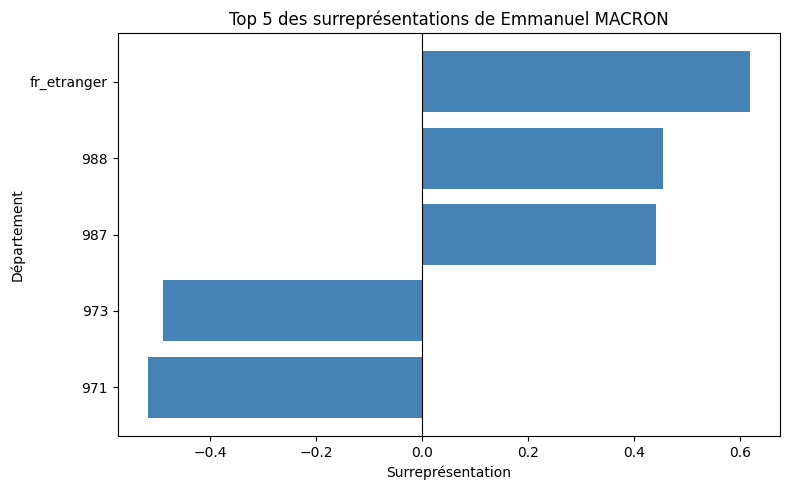

In [30]:
def plot_surrepresentation(candidat, score_departements, n=5):
    """
    Affiche un graphique des principales surreprésentations
    (en valeur absolue) par département pour un candidat donné.
    
    Paramètres:
        candidat (str): Nom exact du candidat
        score_departements (DataFrame): DataFrame avec les colonnes
                                        'candidat', 'code_departement', 'surrepresentation'
        n (int): Nombre de départements à afficher (défaut: 5)
    """
    # Filtrer pour le candidat
    df_candidat = score_departements[score_departements['candidat'] == candidat].copy()

    # Nettoyer les codes département (enlever .0 sans casser 2A, 2B, etc.)
    df_candidat['code_departement'] = df_candidat['code_departement'].apply(
        lambda x: str(int(float(x))) if str(x).replace('.', '').isnumeric() else str(x)
    )

    # Top n par valeur absolue de surreprésentation
    df_top = df_candidat.reindex(
        df_candidat['surrepresentation'].abs().nlargest(n).index
    )

    # Trier pour affichage (plus grand en haut)
    df_top = df_top.sort_values('surrepresentation')

    # Tracé
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.barh(
        df_top['code_departement'],
        df_top['surrepresentation'],
        color='steelblue'
    )

    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Surreprésentation')
    ax.set_ylabel('Département')
    ax.set_title(f'Top {n} des surreprésentations de {candidat}')

    plt.tight_layout()
    plt.show()

# Exemple d'utilisation — adapte le nom exact selon ton DataFrame
plot_surrepresentation('Emmanuel MACRON', score_departements)